# 01. 딥러닝의 기본 리듬

이번 노트북에서는 딥러닝의 가장 기본 흐름을 직접 실행해봅니다.

핵심 리듬은 다음과 같습니다.

```text
입력 -> 예측 -> 손실 -> 수정
```

오늘은 `y = 2x + 1`이라는 아주 쉬운 규칙을 모델이 학습하도록 만들겠습니다.

## 1. 라이브러리 불러오기

라이브러리는 다른 사람이 미리 만들어둔 도구 상자입니다.

- `numpy`: 숫자 배열을 쉽게 다루는 도구
- `matplotlib`: 그래프를 그리는 도구
- keras: 딥러닝 모델을 쉽게 만들고 학습시키는 도구입니다. 현재 환경에서는 TensorFlow를 내부 계산 엔진으로 사용합니다.

In [1]:
import numpy as np  # 숫자 데이터를 배열 형태로 다루기 위한 라이브러리입니다.
import matplotlib.pyplot as plt  # 학습 결과를 그래프로 보기 위한 라이브러리입니다.

from keras.models import Sequential  # 층을 순서대로 쌓는 가장 기본적인 Keras 모델 방식입니다.
from keras.layers import Dense, Input  # Input은 입력 모양을 알려주는 층이고, Dense는 기본 신경망 층입니다.
from keras.optimizers import SGD  # SGD는 손실을 줄이도록 모델 내부 숫자를 조금씩 수정하는 최적화 방법입니다.

## 2. 데이터 준비하기

우리가 모델에게 알려줄 규칙은 다음과 같습니다.

```text
y = 2x + 1
```

예를 들어:

- x가 0이면 y는 1
- x가 1이면 y는 3
- x가 2이면 y는 5

모델은 처음에는 이 규칙을 모릅니다. 아래 데이터만 보고 규칙을 찾아야 합니다.

In [2]:
# x_data는 모델에게 넣어줄 입력값입니다.
# np.array()는 여러 숫자를 하나의 배열로 묶어주는 함수입니다.
# Keras 모델은 보통 입력을 (샘플 수, 특성 수) 형태의 2차원 배열로 받습니다.
# 여기서는 샘플이 5개이고, 각 샘플의 특성은 x 하나뿐이므로 모양은 (5, 1)입니다.
# dtype=np.float32는 숫자를 딥러닝에서 자주 쓰는 실수 형태로 저장하겠다는 뜻입니다.
x_data = np.array([[0], [1], [2], [3], [4]], dtype=np.float32)

# y_data는 모델이 맞혀야 하는 정답값입니다.
# 출력도 예측값과 모양을 맞추기 위해 (5, 1) 형태로 준비합니다.
# 여기서는 y = 2x + 1 규칙에 따라 만든 정답입니다.
y_data = np.array([[1], [3], [5], [7], [9]], dtype=np.float32)

print("입력 x의 모양:", x_data.shape)
print("정답 y의 모양:", y_data.shape)
print("입력 x:", x_data.reshape(-1))
print("정답 y:", y_data.reshape(-1))

입력 x의 모양: (5, 1)
정답 y의 모양: (5, 1)
입력 x: [0. 1. 2. 3. 4.]
정답 y: [1. 3. 5. 7. 9.]


## 3. 데이터를 눈으로 확인하기

모델을 만들기 전에 데이터가 어떤 모양인지 먼저 보는 습관이 중요합니다.

이번 데이터는 아주 단순해서 그래프로 보면 거의 직선입니다.

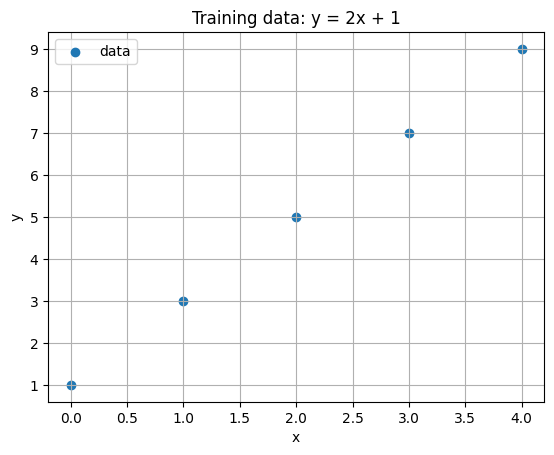

In [3]:
# plt.scatter()는 점 그래프를 그리는 함수입니다.
# x_data와 y_data는 모델용 2차원 배열이므로, 그래프를 그릴 때는 reshape(-1)로 1차원처럼 펼쳐서 사용합니다.
plt.scatter(x_data.reshape(-1), y_data.reshape(-1), label="data")

# 그래프 제목과 축 이름을 붙이면 나중에 결과를 해석하기 쉽습니다.
plt.title("Training data: y = 2x + 1")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

## 4. 모델 만들기

이번에는 가장 단순한 모델을 만듭니다.

```text
y = wx + b
```

Keras에서는 `Input(shape=(1,))`와 `Dense(1)`을 함께 사용해서 만들 수 있습니다.

- `Input(shape=(1,))`: 입력값이 1개라는 뜻입니다. 여기서는 x 하나입니다.
- `Dense(1)`: 출력값이 1개라는 뜻입니다. 여기서는 y 하나입니다.

`Input`은 모델에게 입력 모양을 알려주고, `Dense` 안에는 모델이 학습할 숫자인 `w`와 `b`가 들어 있습니다.

In [4]:
# Sequential은 층을 순서대로 쌓아 모델을 만드는 방식입니다.
# 지금은 Input 층과 Dense 층만 사용하므로 가장 단순한 신경망입니다.
model = Sequential([
    Input(shape=(1,)),  # 입력값이 1개라는 사실을 모델에게 알려줍니다.
    Dense(1)  # 입력 1개를 받아 출력 1개를 만드는 층입니다. 내부에 w와 b가 있습니다.
])

# summary()는 모델 구조를 표처럼 보여주는 메서드입니다.
# Param #가 2인 이유는 학습할 숫자가 w와 b, 총 2개이기 때문입니다.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. 학습 전 예측 보기

모델은 아직 학습하지 않았습니다. 그래서 처음 예측은 엉뚱할 수 있습니다.

먼저 학습 전 예측을 확인해보겠습니다.

In [5]:
# predict()는 모델에게 입력값을 넣고 예측값을 받는 메서드입니다.
# 아직 학습 전이므로 정답과 많이 다를 수 있습니다.
before_pred = model.predict(x_data, verbose=0)

print("학습 전 예측값:")
print(before_pred.reshape(-1))  # reshape(-1)은 보기 쉽게 1차원 배열로 펼치는 기능입니다.

print("정답값:")
print(y_data.reshape(-1))

학습 전 예측값:
[ 0.        -1.0998861 -2.1997721 -3.2996583 -4.3995442]
정답값:
[1. 3. 5. 7. 9.]


## 6. 모델 컴파일하기

모델을 만들었다고 바로 학습할 수 있는 것은 아닙니다.

학습 전에 모델에게 두 가지를 알려줘야 합니다.

1. 얼마나 틀렸는지 재는 기준: `loss`
2. 틀린 것을 어떻게 고칠지 정하는 방법: `optimizer`

이번에는 다음을 사용합니다.

- `loss="mse"`: 평균 제곱 오차. 예측값과 정답의 차이를 재는 회귀용 손실입니다.
- `SGD`: 손실이 줄어드는 방향으로 내부 숫자를 조금씩 수정하는 방법입니다.

In [11]:
# compile()은 모델에게 학습 방법을 설정하는 메서드입니다.
# optimizer는 w와 b를 어떻게 수정할지 정합니다.
# learning_rate는 한 번에 얼마나 크게 수정할지 정합니다. 너무 크면 불안정하고, 너무 작으면 느립니다.
# loss='mse'는 예측값과 정답의 차이를 제곱해서 평균내는 손실 함수입니다.
model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="mse"
)

## 7. 모델 학습하기

이제 모델을 학습시킵니다.

`fit()`은 Keras에서 가장 중요한 메서드 중 하나입니다.

```text
fit = 데이터를 보고 모델 내부 숫자를 고치는 학습 과정
```

- `x_data`: 입력
- `y_data`: 정답
- `epochs=200`: 전체 데이터를 200번 반복해서 학습
- `verbose=0`: 학습 로그를 길게 출력하지 않음

학습 결과는 `history`에 저장됩니다. 여기에는 epoch마다 손실이 어떻게 변했는지가 들어 있습니다.

In [ ]:
# fit()은 모델을 학습시키는 메서드입니다.
# 모델은 x_data를 입력으로 받고 y_data에 가까운 값을 예측하도록 w와 b를 수정합니다.
# history에는 학습 중 손실값이 기록됩니다.
history = model.fit(
    x_data,
    y_data,
    epochs=200,
    verbose=0
)

print("학습 완료")

학습 완료


## 8. 손실이 줄어드는지 확인하기

학습이 잘 됐다면 손실이 점점 줄어들어야 합니다.

손실은 모델이 얼마나 틀렸는지를 나타내는 숫자입니다.

```text
손실이 크다 = 많이 틀렸다
손실이 작다 = 덜 틀렸다
```

처음 손실: 0.0011550247436389327
마지막 손실: 2.8352351364446804e-06


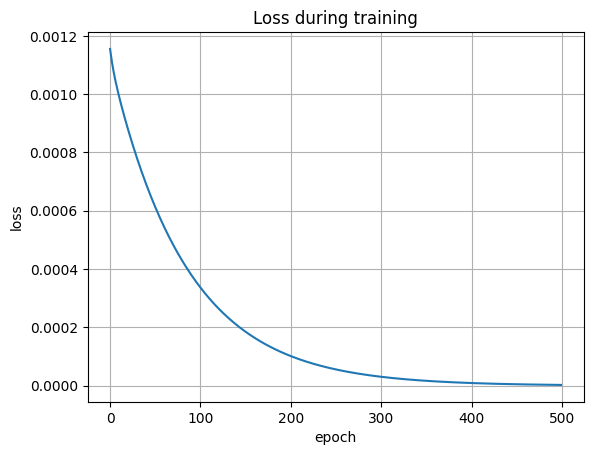

In [13]:
# history.history는 학습 중 기록된 값을 담고 있는 딕셔너리입니다.
# 여기서는 loss라는 이름으로 epoch마다 손실값이 저장되어 있습니다.
loss_values = history.history["loss"]

print("처음 손실:", loss_values[0])
print("마지막 손실:", loss_values[-1])

# plt.plot()은 선 그래프를 그리는 함수입니다.
# 손실이 내려가는 모양을 보면 모델이 학습 중인지 확인할 수 있습니다.
plt.plot(loss_values)
plt.title("Loss during training")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(True)
plt.show()

## 9. 학습 후 예측 보기

이제 모델이 학습을 마쳤습니다.

학습 전 예측과 학습 후 예측을 비교해보겠습니다.

In [14]:
# 학습이 끝난 모델로 다시 예측합니다.
after_pred = model.predict(x_data, verbose=0)

print("입력 x:", x_data.reshape(-1))
print("정답 y:", y_data.reshape(-1))
print("학습 전 예측:", before_pred.reshape(-1))
print("학습 후 예측:", after_pred.reshape(-1))

입력 x: [0. 1. 2. 3. 4.]
정답 y: [1. 3. 5. 7. 9.]
학습 전 예측: [ 0.        -1.0998861 -2.1997721 -3.2996583 -4.3995442]
학습 후 예측: [1.0028912 3.001877  5.000863  6.999849  8.998835 ]


## 10. 학습된 w와 b 확인하기

우리가 원한 진짜 규칙은 다음과 같습니다.

```text
y = 2x + 1
```

즉 모델이 잘 배웠다면 다음 값에 가까워야 합니다.

```text
w = 2
b = 1
```

Keras 모델의 `get_weights()`를 사용하면 학습된 내부 숫자를 확인할 수 있습니다.

In [15]:
# get_weights()는 모델 내부에 학습된 숫자들을 꺼내는 메서드입니다.
# Dense 층 하나에는 가중치 w와 편향 b가 들어 있습니다.
weights, bias = model.get_weights()

# weights는 2차원 배열 형태라서 [0][0]으로 실제 숫자를 꺼냅니다.
learned_w = weights[0][0]

# bias는 배열 형태라서 [0]으로 실제 숫자를 꺼냅니다.
learned_b = bias[0]

print("모델이 학습한 w:", learned_w)
print("모델이 학습한 b:", learned_b)
print("우리가 기대한 w: 2")
print("우리가 기대한 b: 1")

모델이 학습한 w: 1.9989859
모델이 학습한 b: 1.0028912
우리가 기대한 w: 2
우리가 기대한 b: 1


## 11. 새로운 값 예측하기

학습 데이터에는 x=5가 없었습니다.

하지만 규칙을 잘 배웠다면 x=5일 때 y=11에 가까운 값을 예측해야 합니다.

```text
y = 2x + 1
y = 2 * 5 + 1
y = 11
```

In [16]:
# 새로운 입력값을 배열 형태로 만듭니다.
# Keras의 predict()는 보통 여러 개의 입력을 한 번에 받을 수 있는 2차원 형태를 기대합니다.
# 그래서 [[5]]처럼 대괄호를 두 번 사용합니다.
new_x = np.array([[5]], dtype=np.float32)

# 학습된 모델로 새로운 입력값을 예측합니다.
new_y = model.predict(new_x, verbose=0)

print("x=5일 때 모델 예측:", new_y[0][0])
print("x=5일 때 정답 규칙의 값: 11")

x=5일 때 모델 예측: 10.997821
x=5일 때 정답 규칙의 값: 11


## 12. 전체 흐름 다시 정리

이번 노트북에서 한 일은 다음과 같습니다.

```text
1. 입력 x와 정답 y를 준비했다.
2. y = wx + b 형태의 아주 단순한 모델을 만들었다.
3. 학습 전에는 예측이 엉뚱할 수 있음을 확인했다.
4. compile()로 손실과 수정 방법을 정했다.
5. fit()으로 모델을 학습시켰다.
6. 손실이 줄어드는지 확인했다.
7. 학습 후 예측이 정답에 가까워졌는지 확인했다.
8. 모델이 배운 w와 b가 2와 1에 가까운지 확인했다.
9. 새로운 값 x=5를 예측했다.
```

이 흐름이 딥러닝의 기본 리듬입니다.

```text
입력 -> 예측 -> 손실 -> 수정
```

## 과제

아래 질문에 직접 답해보세요.

1. `Input(shape=(1,))`와 `Dense(1)`은 각각 어떤 의미인가요?
2. `compile()`은 어떤 일을 하나요?
3. `fit()`은 어떤 일을 하나요?
4. 손실이 줄어든다는 것은 어떤 뜻인가요?
5. 모델이 학습한 `w`와 `b`는 정답 규칙에 가까웠나요?

추가 실험:

- `epochs=20`으로 줄이면 결과가 어떻게 달라지나요?
- `epochs=500`으로 늘리면 결과가 더 좋아지나요?
- `learning_rate=0.1`로 바꾸면 어떤 일이 생기나요?